# Module 2 — Agentic RAG: A LangGraph Retrieval Loop

**The problem, from Module 1:** one-shot RAG — embed the question, vector-search once, one LLM
call — works well on single-chunk factual questions but falls apart on questions that need
*multiple, targeted* retrievals across documents. A single top-k=5 vector search over "3M vs
Apple R&D" mostly returns 3M chunks (they happen to score higher) and the model has no way to
go back and specifically look for Apple's numbers.

**What we build in this module:**
- An agentic retrieval loop, orchestrated with **LangGraph**, that replaces the one-shot call above
- A `retriever_strategy` node that decides what to search for, given feedback so far
- An `evaluate_retrieval` node that grades sufficiency and loops back for more when needed
- A `generate_answer` node that answers from a curated, distilled knowledge base, not raw chunks
- An `evaluate_answer` node that critiques the answer and can trigger a retry before returning it

**New components introduced:**
- `retrieval.vector` — semantic search over `Chunk.embedding` (rewritten for Module 2: company
  filtering, tool-shaped return values)
- `retrieval.keyword` — fulltext (Lucene) search over the `chunk_text` index
- `retrieval.graph_nav` — page-range lookup for a known `doc_id`
- `agent.tools` — the three retrieval functions wrapped as LangChain `@tool`s
- `agent.state` — `AgentState` (the graph's shared state) and the two structured grading
  schemas, `RetrievalGrade` and `AnswerGrade`
- `agent.prompts` — prompt builders for each LLM-backed node
- `agent.nodes` — the five node functions (each callable standalone, for inspection)
- `agent.graph` — `build_agent()`, wiring the nodes into a compiled LangGraph `StateGraph`

## 1. Recap — Where the One-Shot Baseline Struggles

Same question that closed out Module 1. Neo4j already holds both filings from that module's
ingestion run, so we can call straight into `qa.baseline.ask` and watch it fail the same way.

In [1]:
from financial_advisor.qa.baseline import ask


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [2]:

HARD_QUESTIONS = (
    "Compare 3M's and Apple's approach to research and development investment, "
        "based on their 2025 10-Ks.",
    "How did the number of 3M's U.S. manufacturing facilities change between the 2024 "
        "and 2025 10-K filings?",
)

for q in HARD_QUESTIONS:
    print(f"\n{'=' * 80}")
    print(f"Q: {q}\n")
    print(f"A: {ask(q, k=5)}")


Q: Compare 3M's and Apple's approach to research and development investment, based on their 2025 10-Ks.

A: I don’t know. The provided context includes 3M’s 2024 and 2025 10-K information, but it does not include Apple’s 2025 10-K research and development details, so I can’t make a comparison based only on this context.

Q: How did the number of 3M's U.S. manufacturing facilities change between the 2024 and 2025 10-K filings?

A: I don’t know.


## 2. Graph Model Refactoring — Adding `year` and `company_id` to the indexes

The `company_id` filter above isn't enough on its own: 3M and Apple each have *two* filings in
this corpus (2024, 2025). A `semantic_search` scoped to `company_id="3M"` searches across both
years at once — for a question about one specific filing, both years' chunks compete for the
same top-k budget, with nothing telling the agent which year a given chunk came from. This is
exactly what tripped up the manufacturing-facilities question earlier.

The reason `year` isn't already filterable: it lives on `Document`, not `Chunk` — the level
`semantic_search`/`fulltext_search` actually operate at. This is a small, real graph-model
change: denormalize `Document.year` onto `Chunk.year` (the same idea as `company_id`, which was
already denormalized this way back in Module 1).

Neo4j 2026.01+ lets a vector index declare **additional properties** for in-index pre-filtering
— `CREATE VECTOR INDEX ... WITH [n.prop1, n.prop2] ...`, queried with the Cypher 25 `SEARCH ...
VECTOR INDEX ... WHERE ...` clause. That replaces `semantic_search`'s old `company_id`-only,
over-fetch-then-filter-in-Cypher approach with an exact in-index filter, and folds `year` in for
free. Full-text (Lucene) indexes have no equivalent — `chunk_text` keeps the over-fetch-then-
`WHERE` pattern, just extended to cover `year` too.

`ingestion.schema.apply_agentic_schema()` does both steps: backfills `Chunk.year` for any chunk
that doesn't have it yet, then rebuilds `chunk_embedding` with the additional properties — it
checks the index's current `properties` first and skips the rebuild if already done, so it's
safe to re-run.

In [3]:
from financial_advisor.ingestion.schema import apply_agentic_schema
from financial_advisor.services.embedding_service import embedding_service
from financial_advisor.services.neo4j_service import neo4j_service

apply_agentic_schema(embedding_service.dimensions)

rows = neo4j_service.run_query(
    "SHOW INDEXES YIELD name, type, properties WHERE name = 'chunk_embedding' "
    "RETURN name, type, properties"
)
for r in rows:
    print(r)

  [schema] backfilled year on 0 chunk(s)
  [schema] rebuilt chunk_embedding with company_id/year pre-filters
{'name': 'chunk_embedding', 'type': 'VECTOR', 'properties': ['embedding', 'company_id', 'year']}


Let's check our database using the browser at [http://localhost:7474/browser/](http://localhost:7474/browser/)

Select the right database by using :use \`pack-course\` and run:
- SHOW CONSTRAINTS
- SHOW INDEXES

In [5]:
from financial_advisor.agent.tools import semantic_search

# Same tool, same company — now scoped to one filing year at a time
for yr in (2024, 2025):
    hits = semantic_search.invoke(
        {"query": "manufacturing facilities properties", "k": 2, "company_id": "3M", "year": yr}
    )
    print(f"### year={yr}:")
    for h in hits:
        print(f"  [{h['score']:.3f}] {h['doc_id']}  year={h['year']}")
        print(f"    {h['text'][:200]}\n")

### year=2024:
  [0.784] 3M/3M_2024_10K.pdf  year=2024
    Item 2. Properties
In the U.S., 3M's general offices, corporate research laboratories, and certain division laboratories are located in St. Paul, Minnesota. The Company operates 51 manufacturing facil

  [0.744] 3M/3M_2024_10K.pdf  year=2024
    NOTE 8. Supplemental Balance Sheet Information
Additional supplemental balance sheet information is provided in the table that follows.
(Millions)

2024

2023

Other current assets

Derivative assets-

### year=2025:
  [0.784] 3M/3M_2025_10K.pdf  year=2025
    Item 2. Properties
In the U.S., 3M's general offices, corporate research laboratories, and certain division laboratories are located in St. Paul, Minnesota. The Company operates 48 manufacturing facil

  [0.749] 3M/3M_2025_10K.pdf  year=2025
    Risks Related to Our Products and Customer Preferences
* The Company's results are affected by competitive conditions and customer preferences.
Demand for the Company's products, which imp

## 3. Three Retrieval Tools

To build a proper agentic RAG, we need to give it more tools and let the agent decide which one
to use. Each tool is suited to a different retrieval situation. They're plain LangChain
`@tool`-decorated functions in `agent.tools`, thin wrappers around
`retrieval.vector` / `retrieval.keyword` / `retrieval.graph_nav`:

| Tool | Backing index | Best for |
|---|---|---|
| `semantic_search` | `chunk_embedding` (vector) | broad, conceptual, or comparative questions; unsure of exact wording |
| `fulltext_search` | `chunk_text` (Lucene fulltext) | exact terminology, line items, section titles |
| `get_document_pages` | none — direct `Chunk.doc_id` match | pulling full context once a `doc_id` is already known |

`semantic_search` and `fulltext_search` both accept optional `company_id` (`"3M"` / `"APPLE"`)
and `year` (`2024` / `2025`) filters — critical once a company has more than one filing in the
corpus, since without `year` a search has no way to isolate one 10-K from the other; both years'
chunks compete equally. (Section 2b below covers how `year` filtering is wired into the graph —
it isn't there by default, we add it.) Every returned chunk carries its `doc_id`, so a
`semantic_search` or `fulltext_search` hit is what feeds a later `get_document_pages` call.

Let's call each one directly, exactly as the agent will.

In [6]:
from financial_advisor.agent.tools import fulltext_search, get_document_pages, semantic_search

# Tools are LangChain @tool objects — .invoke(dict) runs them exactly as the agent will call them
hits = semantic_search.invoke(
    {"query": "3M research and development expenses 2025", "k": 3, "company_id": "3M", "year": 2025}
)
print(f"semantic_search -> {len(hits)} chunk(s)\n")
for h in hits:
    print(f"  [{h['score']:.3f}] {h['doc_id']}  chunk_id={h['id']}  pages={h['pages']}")
    print(f"    {h['text'][:200]}\n")

semantic_search -> 3 chunk(s)

  [0.824] 3M/3M_2025_10K.pdf  chunk_id=3M/3M_2025_10K.pdf/81  pages=[53, 54]
    Note 6. Restructuring Actions
Transformation Costs: 3M began a transformation program in 2025 intended as a structural redesign of longer-term manufacturing, distribution, and business process service

  [0.819] 3M/3M_2025_10K.pdf  chunk_id=3M/3M_2025_10K.pdf/56  pages=[34, 35]
    Cash Flows from Investing Activities:
Investments in PP&E enable growth across many diverse markets, helping to meet product demand and increasing manufacturing efficiency. 3M invested $0.9 billion on

  [0.818] 3M/3M_2025_10K.pdf  chunk_id=3M/3M_2025_10K.pdf/70  pages=[40]
    3M Company and Subsidiaries Consolidated Statement of Income (Loss)
Years ended December 31,

(Millions, except per share amounts)

2025

2024

2023

Net sales

$

24,948

$

24,575

$

24,610

Operat



In [7]:
text_hits = fulltext_search.invoke(
    {"query": '"research and development"', "k": 3, "company_id": "APPLE", "year": 2025}
)
print(f"fulltext_search -> {len(text_hits)} chunk(s)\n")
for h in text_hits:
    print(f"  [{h['score']:.3f}] {h['doc_id']}  chunk_id={h['id']}  pages={h['pages']}")
    print(f"    {h['text'][:160]}\n")

fulltext_search -> 3 chunk(s)

  [4.456] APPLE/APPLE_2025_10K.pdf  chunk_id=APPLE/APPLE_2025_10K.pdf/19  pages=[6]
    Research and Development
Because the industries in which the Company competes are characterized by rapid technological advances, the Company's ability to compet

  [4.090] APPLE/APPLE_2025_10K.pdf  chunk_id=APPLE/APPLE_2025_10K.pdf/85  pages=[27]
    Research and Development
The growth in R&D expense during 2025 compared to 2024 was primarily driven by increases in headcount-related expenses and infrastructu

  [3.770] APPLE/APPLE_2025_10K.pdf  chunk_id=APPLE/APPLE_2025_10K.pdf/84  pages=[27]
    Operating Expenses
Operating expenses for 2025, 2024 and 2023 were as follows (dollars in millions):
2025

Change

2024

Change

2023

Research and development




In [8]:
# Given a doc_id already surfaced by one of the tools above, pull specific pages directly
doc_id = hits[0]["doc_id"]
target_pages = hits[0]["pages"]
page_hits = get_document_pages.invoke({"doc_id": doc_id, "pages": target_pages, "limit": 5})

print(f"get_document_pages({doc_id!r}, pages={target_pages}) -> {len(page_hits)} chunk(s)\n")
for h in page_hits:
    print(f"  {h['doc_id']}  chunk_id={h['id']}  pages={h['pages']}")
    print(f"    {h['text'][:160]}\n")

get_document_pages('3M/3M_2025_10K.pdf', pages=[53, 54]) -> 4 chunk(s)

  3M/3M_2025_10K.pdf  chunk_id=3M/3M_2025_10K.pdf/80  pages=[52, 53]
    Note 5. Goodwill and Intangible Assets
Goodwill: The change in the carrying amount of goodwill by business segment was as follows:
(Millions)

Safety and Indust

  3M/3M_2025_10K.pdf  chunk_id=3M/3M_2025_10K.pdf/81  pages=[53, 54]
    Note 6. Restructuring Actions
Transformation Costs: 3M began a transformation program in 2025 intended as a structural redesign of longer-term manufacturing, di

  3M/3M_2025_10K.pdf  chunk_id=3M/3M_2025_10K.pdf/82  pages=[54]
    Note 7. Supplemental Income Statement Information
Other expense (income), net consists of the following:
(Millions)

2025

2024

2023

Interest expense

$

946


  3M/3M_2025_10K.pdf  chunk_id=3M/3M_2025_10K.pdf/83  pages=[54, 55]
    Note 8. Supplemental Equity and Comprehensive Income Information
Common stock ($.01 par value per share) of 3 billion shares is authorized. Preferred stoc

## 4. Shared State

We're going to use LangGraph to describe a more complex agentic workflow: a state machine made
up of nodes and edges, where each node performs a task and moves to the next one.

LangGraph nodes read and write a single shared `AgentState` (a `TypedDict`, defined in
`agent.state`). Each node returns only the keys it changes; LangGraph merges them into the
running state.

Two fields are worth calling out because they carry the whole design:

- **`growing_knowledge`** (str) — a self-contained, cumulative write-up of every fact needed to
  answer the question, rebuilt each retrieval round by the grading node. This — *not* the raw
  retrieved chunks — is all the answer generator ever sees. Retrieved chunks can be noisy,
  redundant, or only partially relevant; forcing an LLM to distill them into
  `growing_knowledge` first keeps the final answering step focused and cheap.
- **`retrieved_chunks`** (list[dict]) — every unique chunk pulled back so far, deduplicated by
  `id` and accumulated *across* retrieval rounds, so a second round doesn't lose what the first
  one found.

Two Pydantic models drive the two evaluation nodes via `with_structured_output`:

- **`RetrievalGrade`** — `sufficient: bool`, the rewritten `growing_knowledge: str`, and
  `feedback: str` for the next retrieval round.
- **`AnswerGrade`** — `accepted: bool`, `next_action: Literal["retry_answer",
  "retry_retrieval", "end"]`, and `feedback: str`.

`next_action` is the crux of the answer-evaluation step: the grading LLM has to look at
`growing_knowledge` and decide *why* the answer is wrong — data missing (go back to retrieval)
versus data present but misused (go back to answer generation).

In [9]:
from financial_advisor.agent.state import initial_state

state = initial_state(HARD_QUESTIONS[0])
for k, v in state.items():
    print(f"  {k}: {v!r}")

  question: "Compare 3M's and Apple's approach to research and development investment, based on their 2025 10-Ks."
  tool_calls: []
  tool_call_log: []
  retrieved_chunks: []
  retrieval_iterations: 0
  growing_knowledge: ''
  retrieval_feedback: ''
  retrieval_sufficient: False
  answer: ''
  answer_attempts: 0
  answer_feedback: ''
  answer_next_action: ''


## 5. The Workflow (as graph)

Five nodes, two LLM-graded decision points. The happy path runs top to bottom once; each side
loop is one place the agent can decide it isn't done yet.

```
                              ┌────────────┐
                              │   START    │
                              └─────┬──────┘
                                    │
                                    ▼
                     ┌──────────────────────────────┐
              ┌─────▶│  1. retriever_strategy_agent │
              │      │     picks tool(s) to call,   │
              │      │     given feedback so far    │
              │      └───────────────┬──────────────┘
              │                      │ tool_calls
              │                      ▼
              │      ┌──────────────────────────────┐
              │      │  2. call_tools               │
              │      │     runs semantic_search /   │
              │      │     fulltext_search /        │
              │      │     get_document_pages       │
              │      └───────────────┬──────────────┘
              │                      │ retrieved_chunks (accumulated)
              │                      ▼
              │     ┌─────────────────────────────────┐
              │     │  3. evaluate_retrieval          │
              └─────┤     rewrites growing_knowledge, │
              retry │     decides: sufficient?        │
                    └───────────────┬─────────────────┘
                                    │ continue (sufficient, or iteration cap)
                                    ▼
                     ┌──────────────────────────────┐
              ┌─────▶│  4. generate_answer          │
              │      │     sees ONLY                │
              │      │     growing_knowledge —      │
              │      │     no raw chunks            │
              │      └───────────────┬──────────────┘
       retry_answer                  │ answer
   (info was there,                  ▼
    answer missed it)  ┌──────────────────────────────┐
              └────────┤  5. evaluate_answer          │
                       │     correct & complete?      │
                       └─────┬────────────────┬───────┘
                             │                │
                        end  │                │ retry_retrieval
                             ▼                │ (info genuinely missing)
                          ┌─────┐             │
                          │ END │             └──────────▶ back to node 1
                          └─────┘
```

Three separate loops, each with a different trigger:
1. **`evaluate_retrieval` → `retriever_strategy_agent`** ("retry") — this round's chunks (plus
   everything before them) aren't enough yet; go search again.
2. **`evaluate_answer` → `generate_answer`** ("retry_answer") — the knowledge is there, the
   answer just didn't use it correctly.
3. **`evaluate_answer` → `retriever_strategy_agent`** ("retry_retrieval") — writing the answer
   exposed a gap that grading the retrieval missed; go search again.

Both retrieval and answering have hard iteration caps (`MAX_RETRIEVAL_ITERATIONS`,
`MAX_ANSWER_ATTEMPTS` in `agent.nodes`) so a stubborn question degrades to "best effort" instead
of looping forever.

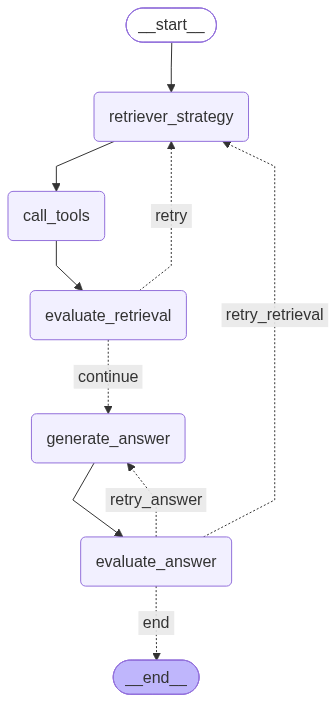

In [10]:
from financial_advisor.agent.graph import build_agent
from IPython.display import Image, display

from financial_advisor.agent.prompts import MODULE_2_STRATEGY_PROMPT
from financial_advisor.agent.tools import MODULE_2_TOOLS

agent = build_agent(MODULE_2_TOOLS, MODULE_2_STRATEGY_PROMPT)

# Cross-check the hand-drawn diagram above against LangGraph's own view of the wiring

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

## 6. Run It on the Question That Broke Module 1

Let's execute it on our hard queries and see how it behaves now.

Every node prints its own progress (see `agent.nodes`), so invoking the compiled graph gives us
a live trace of the loop: which tools got called, whether retrieval was graded sufficient, and
whether the answer was accepted.

In [11]:
result = agent.invoke(initial_state(HARD_QUESTIONS[0]), {"recursion_limit": 50})

print(f"\nretrieval_iterations: {result['retrieval_iterations']}")
print(f"answer_attempts:      {result['answer_attempts']}")
print(f"chunks retrieved:     {len(result['retrieved_chunks'])}")
print(f"\n{'=' * 80}\nANSWER:\n{'=' * 80}\n{result['answer']}")

[strategy] iteration 1: 2 tool call(s) planned
    - semantic_search({'query': 'research and development investment strategy discussion R&D expenses innovation company approach', 'k': 5, 'company_id': '3M', 'year': 2025})
    - semantic_search({'query': 'research and development investment strategy discussion R&D expenses innovation company approach', 'k': 5, 'company_id': 'APPLE', 'year': 2025})
[tools] semantic_search({'query': 'research and development investment strategy discussion R&D expenses innovation company approach', 'k': 5, 'company_id': '3M', 'year': 2025}) -> 5 chunk(s)
[tools] semantic_search({'query': 'research and development investment strategy discussion R&D expenses innovation company approach', 'k': 5, 'company_id': 'APPLE', 'year': 2025}) -> 5 chunk(s)
[grade-retrieval] sufficient=False
    feedback: The current corpus is enough to compare the companies qualitatively, but it does not yet provide Apple’s actual 2025 R&D spending amount or 3M’s actual 2025 R&D expen

### The role of growing knowledge

Compare that against the Module 1 baseline's answer at the top of this notebook: same question,
same underlying data, but here the strategy agent can issue a `semantic_search` scoped to each
`company_id` independently — so both companies' numbers make it into `growing_knowledge` — and
`evaluate_answer` would have looped back to retrieval had one side been missing.

`growing_knowledge` is what actually reached `generate_answer` — the answer generator never saw
`retrieved_chunks` directly:

In [12]:
print(result["growing_knowledge"])

3M’s 2025 10-K portrays R&D as part of a broader, operationally integrated innovation program. It says 3M continues to invest in a range of R&D activities, including application development, product and manufacturing support, product development, and technology development aimed at disruptive innovations; R&D spending also reflects 3M’s continued focus on innovation through growth investments and new product introduction. [doc_id=3M/3M_2025_10K.pdf]

3M defines R&D and related expenses as covering basic scientific research and the application of scientific advances in developing new and improved products and their uses; related expenses include technical support, costs associated with internally developed patents, amortization of certain acquired technology, and gains or losses associated with certain corporate-approved investments in R&D-related ventures. [doc_id=3M/3M_2025_10K.pdf]

3M says internally developed intangible asset costs, such as patents, are expensed as incurred within 

In [13]:
print(f"\n{'=' * 80}\nQUESTION:\n{'=' * 80}\n{HARD_QUESTIONS[1]}\n")
result = agent.invoke(initial_state(HARD_QUESTIONS[1]), {"recursion_limit": 50})
print(f"\nretrieval_iterations: {result['retrieval_iterations']}")
print(f"answer_attempts:      {result['answer_attempts']}")
print(f"chunks retrieved:     {len(result['retrieved_chunks'])}")
print(f"\n{'=' * 80}\nANSWER:\n{'=' * 80}\n{result['answer']}")
print(f"\n{'=' * 80}\nGROWING KNOWLEDGE:\n{'=' * 80}\n{result['growing_knowledge']}\n")



QUESTION:
How did the number of 3M's U.S. manufacturing facilities change between the 2024 and 2025 10-K filings?

[strategy] iteration 1: 2 tool call(s) planned
    - semantic_search({'query': 'U.S. manufacturing facilities number facilities 2024 2025', 'k': 5, 'company_id': '3M'})
    - fulltext_search({'query': '"manufacturing facilities" AND U.S.', 'k': 5, 'company_id': '3M'})
[tools] semantic_search({'query': 'U.S. manufacturing facilities number facilities 2024 2025', 'k': 5, 'company_id': '3M'}) -> 5 chunk(s)
[tools] fulltext_search({'query': '"manufacturing facilities" AND U.S.', 'k': 5, 'company_id': '3M'}) -> 5 chunk(s)
[grade-retrieval] sufficient=True
[answer] attempt #1
[grade-answer] accepted=True next_action=end

retrieval_iterations: 1
answer_attempts:      1
chunks retrieved:     10

ANSWER:
Between the 2024 and 2025 10-K filings, 3M’s U.S. manufacturing facilities decreased from **51 to 48**, a decline of **3 facilities** year over year, while the number of states re

## 7. A few more questions — Easier to Harder

The single-chunk factual questions Module 1 already handled well should still resolve in one
retrieval round here — the agentic loop shouldn't cost extra iterations when it doesn't need
them. The harder case below is one Module 1's baseline got wrong: 3M's U.S. manufacturing
facility count is reported once per filing year (`Item 2. Properties`), not in a joint
year-over-year table, so both years' counts had to compete for one shared top-5 budget and
one of them lost. Here the strategy agent can scope a search to each filing independently and
run a second round if the first wasn't enough.

In [14]:
EXAMPLE_QUESTIONS = [
    "What is 3M's principal executive office address?",  # single-chunk factual — easy
    "What was Apple's total revenue in fiscal year 2024?",  # single-chunk factual — easy
    "How did the number of 3M's U.S. manufacturing facilities change between the 2024 "
    "and 2025 10-K filings?",  # Module 1's baseline said "I don't know" here — hard
]

for q in EXAMPLE_QUESTIONS:
    print(f"\n{'=' * 80}\nQ: {q}\n{'=' * 80}")
    r = agent.invoke(initial_state(q), {"recursion_limit": 50})
    print(
        f"\n[{r['retrieval_iterations']} retrieval round(s), "
        f"{r['answer_attempts']} answer attempt(s), "
        f"{len(r['retrieved_chunks'])} chunk(s) retrieved]"
    )
    print(f"\nA: {r['answer']}")


Q: What is 3M's principal executive office address?
[strategy] iteration 1: 1 tool call(s) planned
    - semantic_search({'query': 'principal executive office address', 'k': 5, 'company_id': '3M', 'year': 2025})
[tools] semantic_search({'query': 'principal executive office address', 'k': 5, 'company_id': '3M', 'year': 2025}) -> 5 chunk(s)
[grade-retrieval] sufficient=True
[answer] attempt #1
[grade-answer] accepted=True next_action=end

[1 retrieval round(s), 1 answer attempt(s), 5 chunk(s) retrieved]

A: 3M’s principal executive office address is **3M Center, St. Paul, Minnesota 55144** (doc_id=3M/3M_2025_10K.pdf, p. 1).

Q: What was Apple's total revenue in fiscal year 2024?
[strategy] iteration 1: 1 tool call(s) planned
    - semantic_search({'query': 'total revenue fiscal year 2024', 'k': 5, 'company_id': 'APPLE', 'year': 2024})
[tools] semantic_search({'query': 'total revenue fiscal year 2024', 'k': 5, 'company_id': 'APPLE', 'year': 2024}) -> 5 chunk(s)
[grade-retrieval] sufficie

## 8. Where this still struggles

The loop is only as good as the graph it searches. `Company → Document → Chunk` is text sliced
out of 10-Ks — it has no notion of *people* and how they connect across companies. 3M's 10-K
does list its executive officers, but for their biographical history it explicitly defers to a
document we never ingested: 3M's proxy statement. Watch what happens when we ask for exactly
that.

In [15]:
STRUGGLE_QUESTION = (
    "Which other companies have 3M's current executive officers previously worked at or "
    "served as directors of?"
)

r = agent.invoke(initial_state(STRUGGLE_QUESTION), {"recursion_limit": 50})
print(
    f"\n[{r['retrieval_iterations']} retrieval round(s), "
    f"{r['answer_attempts']} answer attempt(s), "
    f"{len(r['retrieved_chunks'])} chunk(s) retrieved]"
)
print(f"\nA: {r['answer']}")

[strategy] iteration 1: 1 tool call(s) planned
    - semantic_search({'query': 'current executive officers previous employers served as director companies biography executive officers directors', 'company_id': '3M', 'year': 2025, 'k': 5})
[tools] semantic_search({'query': 'current executive officers previous employers served as director companies biography executive officers directors', 'company_id': '3M', 'year': 2025, 'k': 5}) -> 5 chunk(s)
[grade-retrieval] sufficient=False
    feedback: Use semantic_search or fulltext_search on company_id=3M and year=2025 for executive officer names plus terms like 'formerly', 'previously', 'served as director', 'director of', 'joined 3M', or specific officer names from Item 1. Then, if a promising result returns a doc_id/page, use get_document_pages on that doc_id to pull the surrounding biography context. The current corpus excerpt is missing the executive officer biographies, which are the only place this answer could plausibly be found in the a

With `year` filtering in place (section 2), the strategy agent actually finds more than it
used to here: 3M's 10-K Item 1 has an "Executive Officers of the Registrant" table listing each
officer's *other positions held during 2020-2024* — e.g. William M. Brown at L3Harris
Technologies, Anurag Maheshwari at Otis Worldwide. Once retrieval can scope precisely to
`company_id="3M", year=2024`, that table gets surfaced and cited in the answer, instead of
getting lost in an unscoped search.

But read what the answer itself says about its own limits: that table only covers a five-year
window, and explicitly defers to 3M's proxy statement — never ingested — for full director
biographies and anything earlier. This module's agent doesn't even have a structured
`get_executives` tool to fall back on — `MODULE_2_TOOLS` deliberately excludes it, since
Module 3's `Person`/`ROLE_AT` data doesn't exist yet at this point in the course. Better
retrieval surfaces more of what the corpus *actually contains*; it can't manufacture what isn't
there. That's the real gap Module 3 closes — not "the agent finds nothing" but "the agent finds
a caveated, time-boxed fragment, and a dedicated data source removes the caveats."

## 9. What's Next

Module 3 enriches the graph with `Person`, `Event`, and `Article` nodes (`ROLE_AT`,
`MENTIONED_IN`) — pulling in exactly the executive-history and news data the previous section's
question needed. The retrieval loop built here stays as-is; it just gets more of the graph, and
more tools, to work with.